In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = pd.read_csv("../data/processed/ethiopia_fi_enriched.csv")

data.head()

,record_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,...,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes
0,REC_0001,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,22.0,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Baseline year,NaN
1,REC_0002,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,35.0,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,NaN,NaN
2,REC_0003,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,46.0,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,NaN,NaN
3,REC_0004,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,56.0,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Gender disaggregated,NaN
4,REC_0005,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,36.0,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Gender disaggregated,NaN


record_type
observation    40
event          10
impact_link    10
target          3
Name: count, dtype: int64


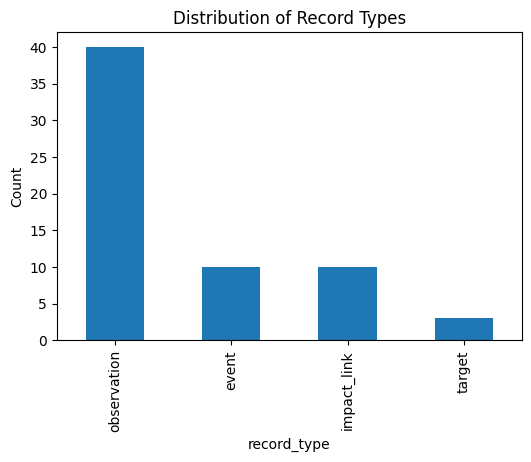

In [2]:
record_counts = data["record_type"].value_counts()

print(record_counts)

record_counts.plot(
    kind="bar",
    figsize=(6,4),
    title="Distribution of Record Types"
)

plt.ylabel("Count")
plt.show()

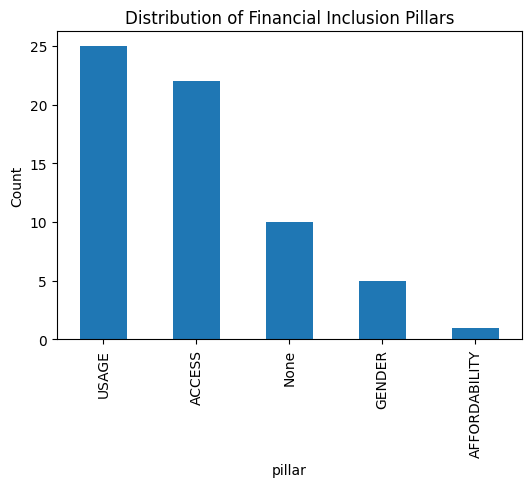

In [3]:
pillar_counts = data["pillar"].fillna("None").value_counts()

pillar_counts.plot(
    kind="bar",
    figsize=(6,4),
    title="Distribution of Financial Inclusion Pillars"
)

plt.ylabel("Count")
plt.show()

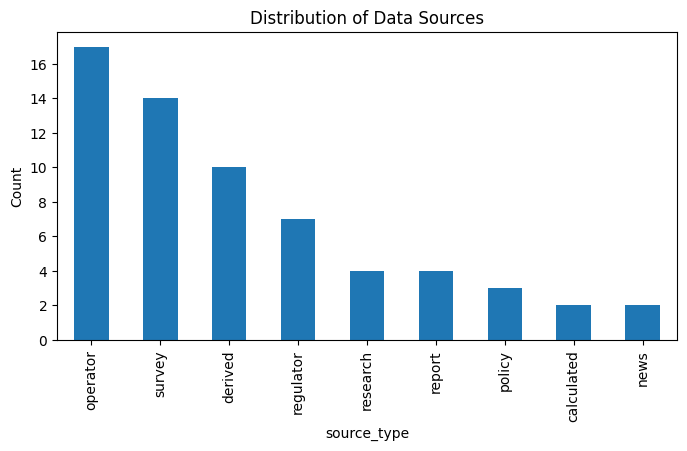

In [4]:
source_counts = data["source_type"].value_counts()

source_counts.plot(
    kind="bar",
    figsize=(8,4),
    title="Distribution of Data Sources"
)

plt.ylabel("Count")
plt.show()

In [6]:
data["observation_date"] = pd.to_datetime(
    data["observation_date"],
    errors="coerce"
)

data["year"] = data["observation_date"].dt.year

In [7]:
coverage = (
    data[data["record_type"]=="observation"]
    .groupby(["year","indicator"])
    .size()
    .unstack(fill_value=0)
)

coverage

indicator,Account Ownership Rate,Account Ownership Gender Gap,Mobile Money Account Rate,4G Population Coverage,Data Affordability Index,Fayda Digital ID Enrollment,Female Mobile Money Account Share,M-Pesa 90-Day Active Users,M-Pesa Registered Users,Mobile Money Activity Rate,Mobile Phone Gender Gap,P2P Transaction Count,ATM Transaction Count,ATM Transaction Value,Mobile Subscription Penetration,P2P Transaction Value,P2P/ATM Crossover Ratio,Telebirr Registered Users,Telebirr Transaction Value
year,,,,,,,,,,,,,,,,,,,
2014.0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2017.0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2021.0,3,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2023.0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2024.0,1,1,1,0,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0
2025.0,0,0,0,1,0,2,0,0,0,0,0,1,1,1,1,1,1,1,1


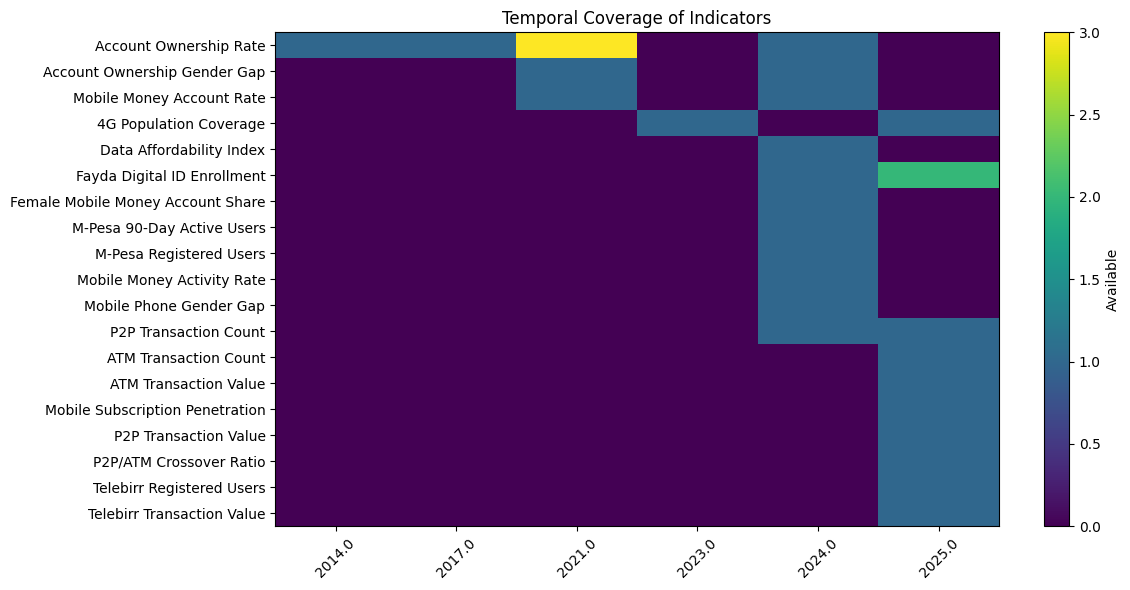

In [8]:
plt.figure(figsize=(12,6))

plt.imshow(
    coverage.T,
    aspect="auto"
)

plt.colorbar(label="Available")

plt.xticks(
    range(len(coverage.index)),
    coverage.index,
    rotation=45
)

plt.yticks(
    range(len(coverage.columns)),
    coverage.columns
)

plt.title("Temporal Coverage of Indicators")

plt.tight_layout()

plt.show()

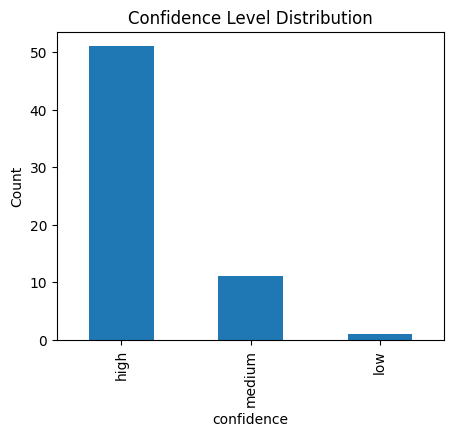

In [9]:
confidence = data["confidence"].value_counts()

confidence.plot(
    kind="bar",
    figsize=(5,4),
    title="Confidence Level Distribution"
)

plt.ylabel("Count")

plt.show()

In [10]:
missing = data.isnull().sum().sort_values(ascending=False)

missing

region                 63
category               53
evidence_basis         53
lag_months             53
value_text             53
impact_estimate        53
impact_magnitude       53
impact_direction       53
period_start           53
period_end             53
relationship_type      53
related_indicator      53
notes                  43
collection_date        33
source_url             22
original_text          20
year                   20
value_numeric          20
observation_date       20
unit                   20
indicator_direction    20
pillar                 10
comparable_country     10
record_type             0
indicator               0
indicator_code          0
collected_by            0
value_type              0
source_name             0
fiscal_year             0
gender                  0
confidence              0
location                0
source_type             0
record_id               0
dtype: int64

In [11]:
indicator_counts = (
    data[data.record_type=="observation"]
    .groupby("indicator")
    .size()
    .sort_values()
)

indicator_counts

indicator
3G Population Coverage               1
Received Wages Digitally             1
P2P/ATM Crossover Ratio              1
P2P Transaction Value                1
Mobile Subscription Penetration      1
Mobile Phone Gender Gap              1
Mobile Money Activity Rate           1
Mobile Money Account Ownership       1
Mobile Connections                   1
M-Pesa 90-Day Active Users           1
Mobile Connection Penetration        1
Digital Payment Adoption             1
Data Affordability Index             1
ATM Transaction Value                1
ATM Transaction Count                1
Female Mobile Money Account Share    1
Telebirr Transaction Value           1
M-Pesa Registered Users              2
Telebirr Registered Users            2
Mobile Money Account Rate            2
Account Ownership Gender Gap         2
P2P Transaction Count                2
Fayda Digital ID Enrollment          3
4G Population Coverage               3
Account Ownership Rate               7
dtype: int64

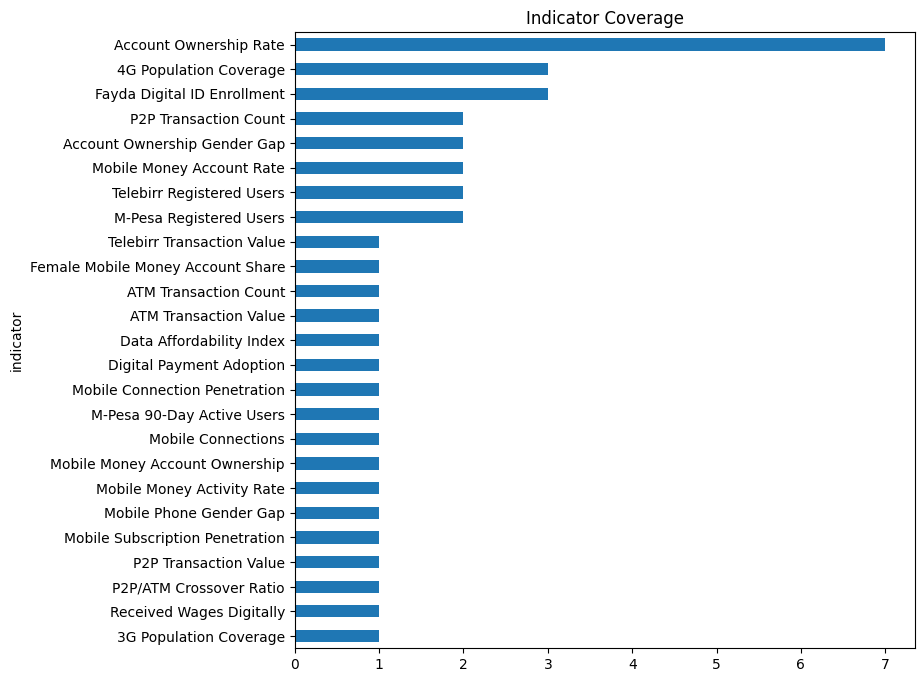

In [12]:
indicator_counts.plot(
    kind="barh",
    figsize=(8,8)
)

plt.title("Indicator Coverage")

plt.show()

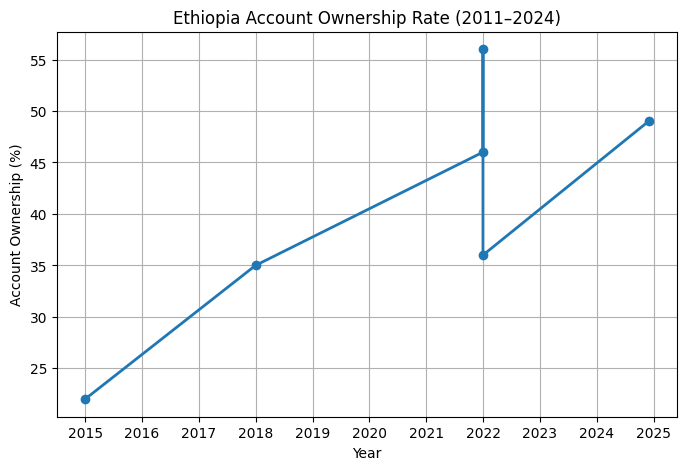

In [13]:
access = data[
    (data["record_type"] == "observation") &
    (data["indicator"] == "Account Ownership Rate")
].copy()

access = access.sort_values("observation_date")

plt.figure(figsize=(8,5))

plt.plot(
    access["observation_date"],
    access["value_numeric"],
    marker="o",
    linewidth=2
)

plt.title("Ethiopia Account Ownership Rate (2011–2024)")
plt.xlabel("Year")
plt.ylabel("Account Ownership (%)")
plt.grid(True)

plt.show()

In [14]:
access["growth_pp"] = access["value_numeric"].diff()

access[["year","value_numeric","growth_pp"]]

,year,value_numeric,growth_pp
0,2014.0,22.0,NaN
1,2017.0,35.0,13.0
2,2021.0,46.0,11.0
3,2021.0,56.0,10.0
4,2021.0,36.0,-20.0
5,2024.0,49.0,13.0
45,NaN,49.0,0.0


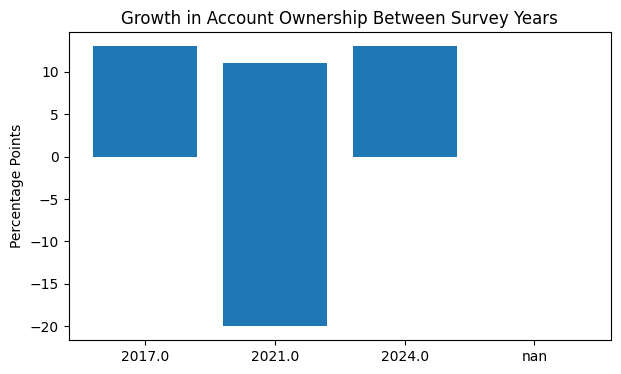

In [15]:
plt.figure(figsize=(7,4))

plt.bar(
    access["year"].astype(str),
    access["growth_pp"]
)

plt.title("Growth in Account Ownership Between Survey Years")
plt.ylabel("Percentage Points")

plt.show()

In [16]:
gender = data[
    data["indicator"].str.contains("Gender", case=False, na=False)
]

gender[
    [
        "indicator",
        "year",
        "value_numeric"
    ]
]

,indicator,year,value_numeric
26,Account Ownership Gender Gap,2021.0,20.0
27,Account Ownership Gender Gap,2024.0,18.0
29,Mobile Phone Gender Gap,2024.0,24.0


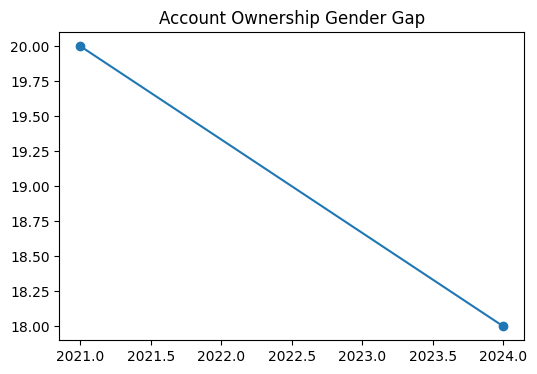

In [17]:
gap = data[
    data["indicator"]=="Account Ownership Gender Gap"
]

plt.figure(figsize=(6,4))

plt.plot(
    gap["year"],
    gap["value_numeric"],
    marker="o"
)

plt.title("Account Ownership Gender Gap")

plt.show()

In [18]:
sorted(data["indicator"].unique())

['3G Population Coverage',
 '4G Population Coverage',
 'ATM Transaction Count',
 'ATM Transaction Value',
 'Account Ownership Gender Gap',
 'Account Ownership Rate',
 'Data Affordability Index',
 'Digital Payment Adoption',
 'EthioPay Instant Payment System Launch',
 'Fayda Digital ID Enrollment',
 'Fayda Digital ID Impact',
 'Fayda Digital ID Program Rollout',
 'Female Mobile Money Account Share',
 'Foreign Exchange Liberalization',
 'Foreign Exchange Liberalization Impact',
 'M-Pesa 90-Day Active Users',
 'M-Pesa EthSwitch Integration',
 'M-Pesa Ethiopia Launch',
 'M-Pesa Launch Impact',
 'M-Pesa Registered Users',
 'Mobile Connection Penetration',
 'Mobile Connections',
 'Mobile Money Account Ownership',
 'Mobile Money Account Rate',
 'Mobile Money Activity Rate',
 'Mobile Phone Gender Gap',
 'Mobile Subscription Penetration',
 'NFIS-II Strategy Impact',
 'NFIS-II Strategy Launch',
 'P2P Surpasses ATM Impact',
 'P2P Transaction Count',
 'P2P Transaction Count Surpasses ATM',
 'P2P T

In [19]:
usage_indicators = [
    "Mobile Money Account Rate",
    "Telebirr Registered Users",
    "M-Pesa Registered Users",
    "Mobile Money Activity Rate",
]

usage = data[
    data["indicator"].isin(usage_indicators)
]

In [20]:
infra = data[
    data["indicator"].isin([
        "4G Population Coverage",
        "Mobile Subscription Penetration",
        "Fayda Digital ID Enrollment"
    ])
]

In [21]:
events = data[
    data["record_type"]=="event"
]

events[
[
"observation_date",
"indicator",
"category"
]
].sort_values("observation_date")

,observation_date,indicator,category
33,2021-05-17,Telebirr Launch,product_launch
41,2021-09-01,NFIS-II Strategy Launch,policy
34,2022-08-01,Safaricom Ethiopia Commercial Launch,market_entry
35,2023-08-01,M-Pesa Ethiopia Launch,product_launch
36,2024-01-01,Fayda Digital ID Program Rollout,infrastructure
37,2024-07-29,Foreign Exchange Liberalization,policy
38,2024-10-01,P2P Transaction Count Surpasses ATM,milestone
39,2025-10-27,M-Pesa EthSwitch Integration,partnership
42,2025-12-15,Safaricom Ethiopia Price Increase,pricing
40,2025-12-18,EthioPay Instant Payment System Launch,infrastructure


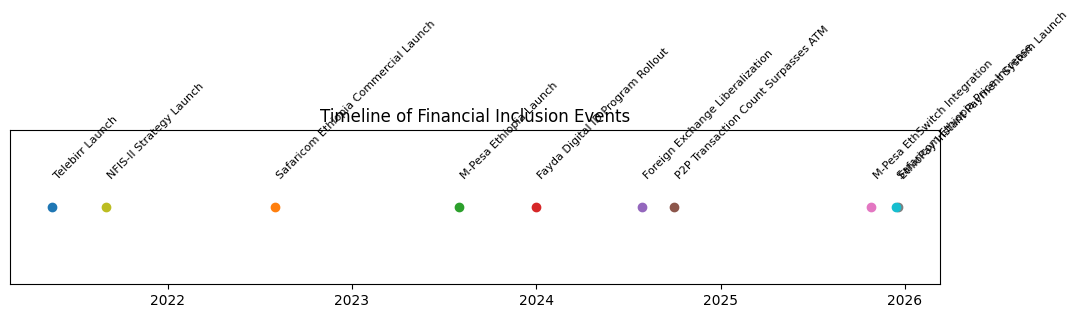

In [22]:
plt.figure(figsize=(12,2))

for _, row in events.iterrows():
    plt.scatter(
        row["observation_date"],
        1
    )
    
    plt.text(
        row["observation_date"],
        1.02,
        row["indicator"],
        rotation=45,
        fontsize=8
    )

plt.yticks([])

plt.title("Timeline of Financial Inclusion Events")

plt.show()

In [23]:
wide = (
    data[
        data["record_type"]=="observation"
    ]
    .pivot_table(
        index="year",
        columns="indicator",
        values="value_numeric",
        aggfunc="mean"
    )
)

In [24]:
corr = wide.corr(numeric_only=True)

corr

indicator,4G Population Coverage,ATM Transaction Count,ATM Transaction Value,Account Ownership Gender Gap,Account Ownership Rate,Data Affordability Index,Fayda Digital ID Enrollment,Female Mobile Money Account Share,M-Pesa 90-Day Active Users,M-Pesa Registered Users,Mobile Money Account Rate,Mobile Money Activity Rate,Mobile Phone Gender Gap,Mobile Subscription Penetration,P2P Transaction Count,P2P Transaction Value,P2P/ATM Crossover Ratio,Telebirr Registered Users,Telebirr Transaction Value
indicator,,,,,,,,,,,,,,,,,,,
4G Population Coverage,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ATM Transaction Count,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ATM Transaction Value,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Account Ownership Gender Gap,NaN,NaN,NaN,1.0,-1.0,NaN,NaN,NaN,NaN,NaN,-1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Account Ownership Rate,NaN,NaN,NaN,-1.0,1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Data Affordability Index,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fayda Digital ID Enrollment,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN
Female Mobile Money Account Share,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
M-Pesa 90-Day Active Users,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


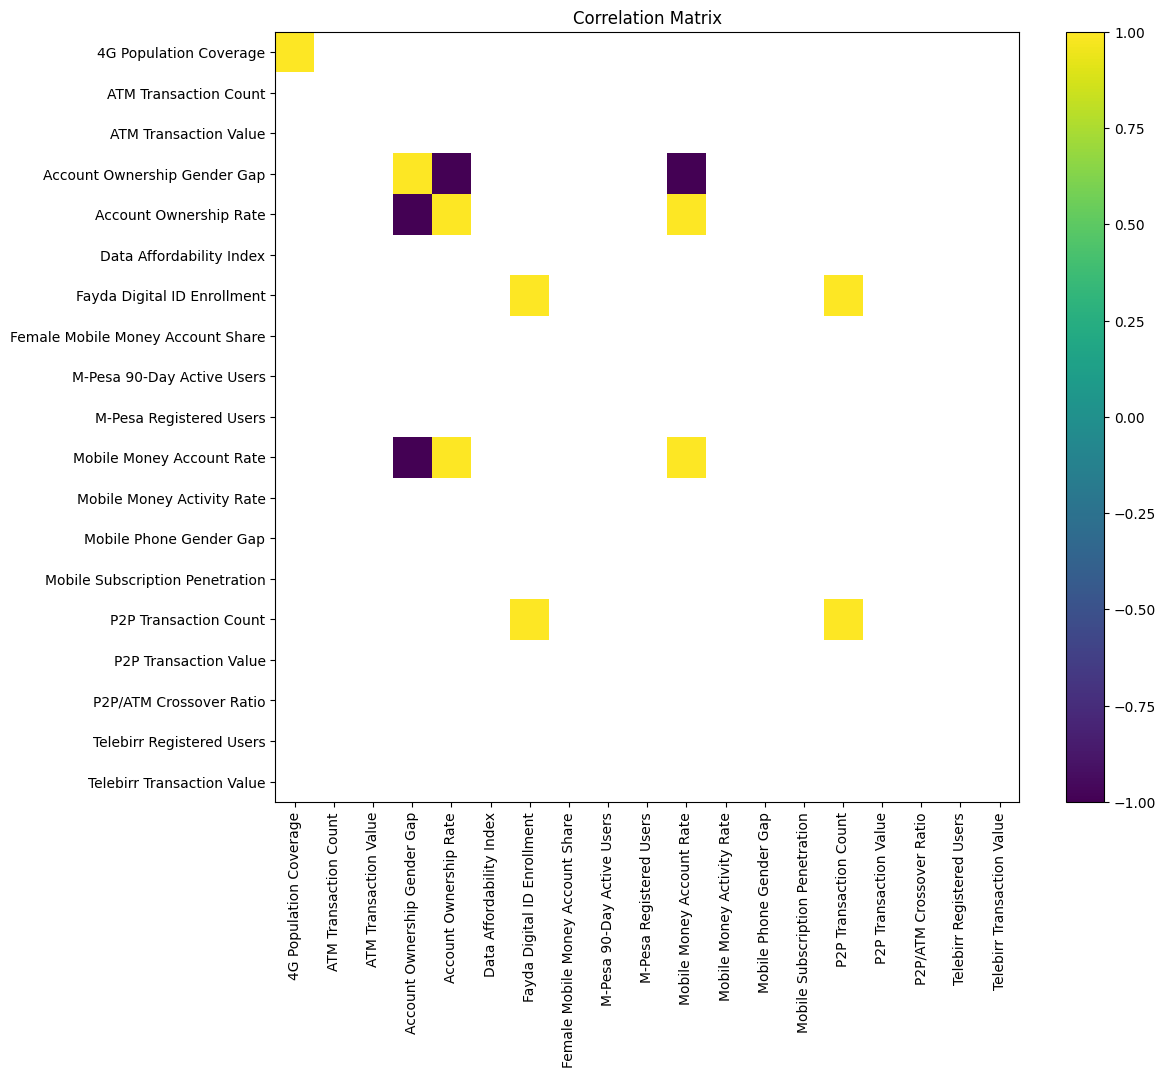

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,10))
plt.imshow(corr, aspect="auto")
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Matrix")

plt.show()

### Interpretation

The correlation matrix suggests that infrastructure indicators such as mobile subscription penetration, 4G population coverage, and Fayda Digital ID enrollment tend to move in the same direction as financial inclusion indicators. However, these relationships should be interpreted cautiously because the dataset contains relatively few annual observations and several indicators have limited historical coverage. Consequently, the correlations are exploratory and primarily intended to identify potential predictors for the forecasting stage rather than establish causal relationships.

In [26]:
events = data[data["record_type"] == "event"].copy()

events = events.sort_values("observation_date")

events[["observation_date","indicator","category"]]

,observation_date,indicator,category
33,2021-05-17,Telebirr Launch,product_launch
41,2021-09-01,NFIS-II Strategy Launch,policy
34,2022-08-01,Safaricom Ethiopia Commercial Launch,market_entry
35,2023-08-01,M-Pesa Ethiopia Launch,product_launch
36,2024-01-01,Fayda Digital ID Program Rollout,infrastructure
37,2024-07-29,Foreign Exchange Liberalization,policy
38,2024-10-01,P2P Transaction Count Surpasses ATM,milestone
39,2025-10-27,M-Pesa EthSwitch Integration,partnership
42,2025-12-15,Safaricom Ethiopia Price Increase,pricing
40,2025-12-18,EthioPay Instant Payment System Launch,infrastructure


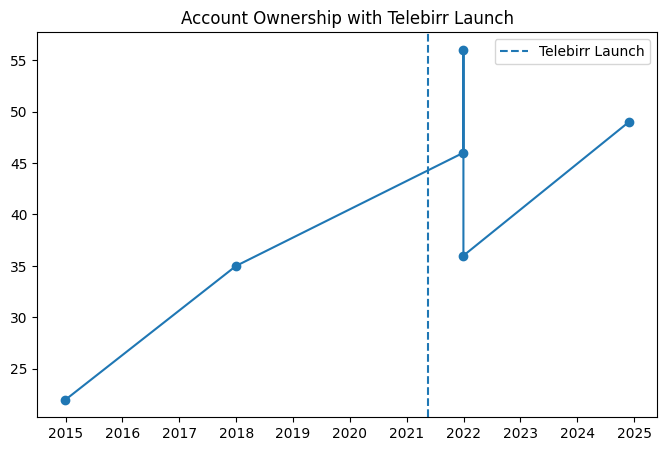

In [28]:
plt.figure(figsize=(8,5))

plt.plot(
    access["observation_date"],
    access["value_numeric"],
    marker="o"
)

plt.axvline(
    pd.Timestamp("2021-05-17"),
    linestyle="--",
    label="Telebirr Launch"
)

plt.legend()

plt.title("Account Ownership with Telebirr Launch")

plt.show()

In [29]:
infra = data[
    data["indicator"].isin([
        "4G Population Coverage",
        "Mobile Subscription Penetration",
        "Fayda Digital ID Enrollment"
    ])
]

infra

,record_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,...,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes,year
8,REC_0009,observation,NaN,ACCESS,4G Population Coverage,ACC_4G_COV,higher_better,37.5,NaN,percentage,...,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Before major expansion,NaN,2023.0
9,REC_0010,observation,NaN,ACCESS,4G Population Coverage,ACC_4G_COV,higher_better,70.8,NaN,percentage,...,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,4G coverage doubled from 37.5% to 70.8%,Major infrastructure investment,NaN,2025.0
10,REC_0011,observation,NaN,ACCESS,Mobile Subscription Penetration,ACC_MOBILE_PEN,higher_better,61.4,NaN,percentage,...,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,93.7M connections / 152.7M population,NaN,2025.0
11,REC_0012,observation,NaN,ACCESS,Fayda Digital ID Enrollment,ACC_FAYDA,higher_better,8000000.0,NaN,count,...,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,NaN,NaN,2024.0
12,REC_0013,observation,NaN,ACCESS,Fayda Digital ID Enrollment,ACC_FAYDA,higher_better,12000000.0,NaN,count,...,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,Over 12 million registered as of February 2025,NaN,NaN,2025.0
13,REC_0014,observation,NaN,ACCESS,Fayda Digital ID Enrollment,ACC_FAYDA,higher_better,15000000.0,NaN,count,...,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,NaN,NaN,2025.0
31,REC_0032,target,NaN,ACCESS,Fayda Digital ID Enrollment,ACC_FAYDA,higher_better,90000000.0,NaN,count,...,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,90M by 2028 target,NaN,2028.0
50,OBS_0038,observation,NaN,USAGE,4G Population Coverage,COVERAGE_4G,higher_better,33.0,NaN,percentage,...,NaN,NaN,NaN,NaN,NaN,Your Name,2026-07-21,33% population covered by 4G.,Digital infrastructure.,NaN


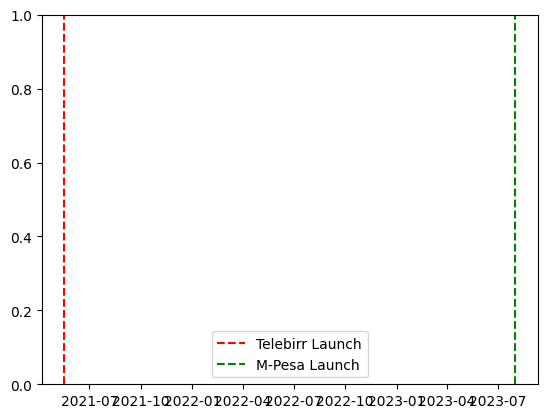

In [35]:
plt.axvline(
    pd.Timestamp("2021-05-17"),
    color="red",
    linestyle="--",
    label="Telebirr Launch"
)

plt.axvline(
    pd.Timestamp("2023-08-01"),
    color="green",
    linestyle="--",
    label="M-Pesa Launch"
)

plt.legend()

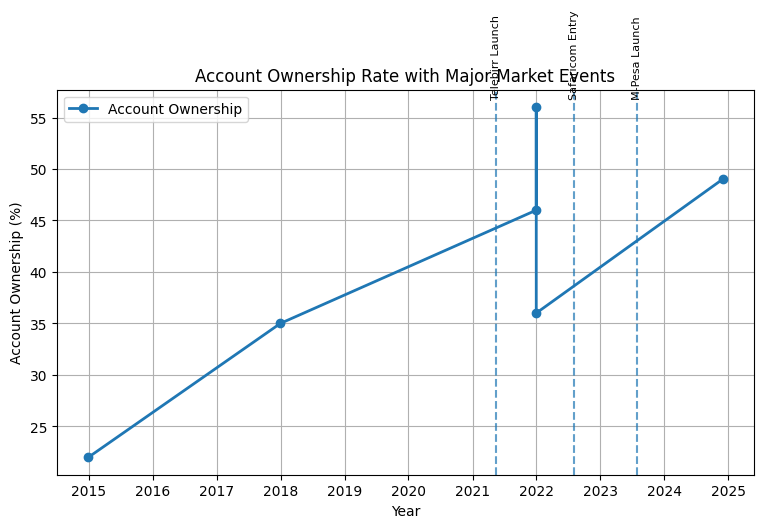

In [36]:
# Account Ownership Trend with Major Events

access = data[
    (data["record_type"] == "observation") &
    (data["indicator"] == "Account Ownership Rate")
].sort_values("observation_date")

plt.figure(figsize=(9,5))

plt.plot(
    access["observation_date"],
    access["value_numeric"],
    marker="o",
    linewidth=2,
    label="Account Ownership"
)

# Major events
events_to_show = {
    "Telebirr Launch": "2021-05-17",
    "Safaricom Entry": "2022-08-01",
    "M-Pesa Launch": "2023-08-01"
}

for label, date in events_to_show.items():
    plt.axvline(
        pd.Timestamp(date),
        linestyle="--",
        alpha=0.7
    )
    plt.text(
        pd.Timestamp(date),
        access["value_numeric"].max()+1,
        label,
        rotation=90,
        fontsize=8,
        ha="center"
    )

plt.title("Account Ownership Rate with Major Market Events")
plt.xlabel("Year")
plt.ylabel("Account Ownership (%)")
plt.grid(True)
plt.legend()

plt.show()

In [37]:
# Create wide-format dataset

wide = (
    data[data["record_type"] == "observation"]
    .pivot_table(
        index="year",
        columns="indicator",
        values="value_numeric",
        aggfunc="mean"
    )
)

wide.head()

indicator,4G Population Coverage,ATM Transaction Count,ATM Transaction Value,Account Ownership Gender Gap,Account Ownership Rate,Data Affordability Index,Fayda Digital ID Enrollment,Female Mobile Money Account Share,M-Pesa 90-Day Active Users,M-Pesa Registered Users,Mobile Money Account Rate,Mobile Money Activity Rate,Mobile Phone Gender Gap,Mobile Subscription Penetration,P2P Transaction Count,P2P Transaction Value,P2P/ATM Crossover Ratio,Telebirr Registered Users,Telebirr Transaction Value
year,,,,,,,,,,,,,,,,,,,
2014.0,NaN,NaN,NaN,NaN,22.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017.0,NaN,NaN,NaN,NaN,35.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021.0,NaN,NaN,NaN,20.0,46.0,NaN,NaN,NaN,NaN,NaN,4.70,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023.0,37.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024.0,NaN,NaN,NaN,18.0,49.0,2.0,8000000.0,14.0,7100000.0,10800000.0,9.45,66.0,24.0,NaN,49700000.0,NaN,NaN,NaN,NaN


In [38]:
corr = wide.corr(numeric_only=True)

corr.round(2)

indicator,4G Population Coverage,ATM Transaction Count,ATM Transaction Value,Account Ownership Gender Gap,Account Ownership Rate,Data Affordability Index,Fayda Digital ID Enrollment,Female Mobile Money Account Share,M-Pesa 90-Day Active Users,M-Pesa Registered Users,Mobile Money Account Rate,Mobile Money Activity Rate,Mobile Phone Gender Gap,Mobile Subscription Penetration,P2P Transaction Count,P2P Transaction Value,P2P/ATM Crossover Ratio,Telebirr Registered Users,Telebirr Transaction Value
indicator,,,,,,,,,,,,,,,,,,,
4G Population Coverage,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ATM Transaction Count,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ATM Transaction Value,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Account Ownership Gender Gap,NaN,NaN,NaN,1.0,-1.0,NaN,NaN,NaN,NaN,NaN,-1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Account Ownership Rate,NaN,NaN,NaN,-1.0,1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Data Affordability Index,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fayda Digital ID Enrollment,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN
Female Mobile Money Account Share,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
M-Pesa 90-Day Active Users,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Data Quality Assessment

## Strengths

- Most observations originate from high-confidence sources such as the World Bank Global Findex, National Bank of Ethiopia, Ethio Telecom, and Safaricom Ethiopia.
- The dataset integrates survey data, operator statistics, infrastructure indicators, policy events, and strategic targets within a unified schema.
- Event records and impact links provide useful contextual information for subsequent forecasting and intervention analysis.

## Limitations

- Global Findex observations are available only every three years, resulting in sparse historical time series.
- Several enriched indicators contain only one or two observations, limiting statistical analysis.
- Regional and urban–rural disaggregated data are largely unavailable.
- Indicators originate from different organizations with different reporting frequencies and methodologies.
- Correlation analysis should therefore be interpreted as exploratory rather than statistically conclusive.

# Key Insights

### 1. Financial inclusion growth has slowed

Account ownership increased from 46% in 2021 to only 49% in 2024, representing the smallest increase since Global Findex reporting began for Ethiopia.

### 2. Rapid digital finance expansion did not immediately translate into higher account ownership

Telebirr exceeded 54 million registered users and M-Pesa entered the market in 2023, yet formal account ownership grew only modestly. This suggests that many new digital finance users already possessed financial accounts.

### 3. Digital infrastructure is improving rapidly

Expansion of 4G coverage, increasing mobile subscription penetration, and growth in Fayda Digital ID enrollment create favorable conditions for future financial inclusion.

### 4. Gender disparities remain

Although the account ownership gender gap narrowed slightly between 2021 and 2024, women continue to experience lower financial inclusion than men.

### 5. Additional operator and infrastructure data improve forecasting

Because Global Findex surveys occur only every three years, operator statistics, infrastructure indicators, and policy events provide valuable supplementary information for forecasting future Access and Usage indicators.